# Libraries

In [35]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from spectra_bean.utils import PathManager
from spectral import *
import matplotlib.pyplot as plt
import rasterio
import cv2
import numpy as np
import spectral as spy

# Load image

In [22]:
# Open the .hdr file (which automatically loads the .bsq data)
path_hdr_file = PathManager().get_abs_path_file('rionegro01_mosaic_geom_atm.hdr')
path_bsq_file = PathManager().get_abs_path_file('rionegro01_mosaic_geom_atm.bsq')

In [23]:
img = spectral.open_image(path_hdr_file)

In [24]:
img

	Data Source:   'c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\raw\rionegro01_mosaic_geom_atm.bsq'
	# Rows:           3660
	# Samples:        3438
	# Bands:           379
	Interleave:        BSQ
	Quantization:  16 bits
	Data format:     int16

In [25]:
# Access the wavelegths associated with each band
wavelegths = img.bands.centers
n_wavelegths = len(wavelegths)

In [26]:
print('Shape of hyperspectral data:', img.shape)
print('Number of bands:', img.shape[2])
print('wavelegths:', wavelegths)

Shape of hyperspectral data: (3660, 3438, 379)
Number of bands: 379
wavelegths: [411.03182, 413.93909, 416.84635, 419.75362, 422.66089, 425.56816, 428.47543, 431.38269, 434.28996, 437.19723, 440.1045, 443.01177, 445.91904, 448.8263, 451.73357, 454.64084, 457.54811, 460.45538, 463.36264, 466.26991, 469.17718, 472.08445, 474.99172, 477.89898, 480.80625, 483.71352, 486.62079, 489.52806, 492.43533, 495.34259, 498.24986, 501.15713, 504.0644, 506.97167, 509.87894, 512.7862, 515.69347, 518.60074, 521.50801, 524.41528, 527.32254, 530.22981, 533.13708, 536.04435, 538.95162, 541.85889, 544.76615, 547.67342, 550.58069, 553.48796, 556.39523, 559.30249, 562.20976, 565.11703, 568.0243, 570.93157, 573.83883, 576.7461, 579.65337, 582.56064, 585.46791, 588.37517, 591.28244, 594.18971, 597.09698, 600.00425, 602.91152, 605.81878, 608.72605, 611.63332, 614.54059, 617.44786, 620.35512, 623.26239, 626.16966, 629.07693, 631.9842, 634.89147, 637.79873, 640.706, 643.61327, 646.52054, 649.42781, 652.33508, 655.

In [27]:
for key, value in img.metadata.items():
    print(f"{key}: {value}")

description: PARGE/ATCOR Mosaicking from: ,rionegro01_02_Mjolnir_float32_geo_VS620_rfl.bsq,rionegro01_03_Mjolnir_float32_geo_VS620_rfl.bsq,rionegro01_04_Mjolnir_float32_geo_VS620_rfl.bsq,rionegro01_05_Mjolnir_float32_geo_VS620_rfl.bsq
samples: 3438
lines: 3660
bands: 379
header offset: 0
file type: ENVI Standard
data type: 2
interleave: BSQ
sensor type: HYSPEX
byte order: 0
x start: 1
y start: 1
map info: ['UTM', '1', '1', '453983.380', '677786.010', '0.0200000', '0.0200000', '18', 'North', 'WGS-84', 'units=Meter']
coordinate system string: ['PROJCS["WGS_1984_UTM_Zone_18N"', 'GEOGCS["GCS_WGS_1984"', 'DATUM["D_WGS_1984"', 'SPHEROID["WGS_1984"', '6378137.0', '298.257223563]]', 'PRIMEM["Greenwich"', '0.0]', 'UNIT["Degree"', '0.0174532925199433]]', 'PROJECTION["Transverse_Mercator"]', 'PARAMETER["False_Easting"', '500000.0]', 'PARAMETER["False_Northing"', '0.0]', 'PARAMETER["Central_Meridian"', '-75.0]', 'PARAMETER["Scale_Factor"', '0.9996]', 'PARAMETER["Latitude_Of_Origin"', '0.0]', 'UNIT

# 2) Lectura, normalización y máscaras
Puntos críticos:

Sin cargar todo a RAM: usar memmap.
Reflectancia física: dividir por 10000.
Máscaras: aplicar ignore y background.
Clipping: por seguridad, limitar reflectancia a [0, 1.2] (algunas bandas pueden saturar ligeramente tras correcciones)

In [28]:

img = spy.envi.open(path_hdr_file)            # memmap, no carga todo
cube = img.load()                        # aún es lazy/memmap con spectral

In [ ]:

# Metadatos útiles
hdr = img.metadata
wavelengths = np.array([float(w) for w in hdr.get('wavelength', [])]) if 'wavelength' in hdr else None
n_wavelegths = len(wavelengths)
fwhm = np.array([float(f) for f in hdr.get('fwhm', [])]) if 'fwhm' in hdr else None
scale = float(hdr.get('reflectance scale factor', 10000.0))
ignore_vals = set()
if 'data ignore value' in hdr: ignore_vals.add(float(hdr['data ignore value']))
if 'background' in hdr: ignore_vals.add(float(hdr['background']))

In [31]:
# Normalización a reflectancia física [~0-1]
# NOTA: cube es int16; convertir bajo demanda al operar
def to_reflectance(band_i):
    band = cube.read_band(band_i).astype(np.float32)
    # Construir máscara de no-datos
    mask = np.zeros_like(band, dtype=bool)
    for v in ignore_vals:
        mask |= (band == v)
    # Convertir y clip
    refl = band / scale
    refl[(refl < 0) | (refl > 1.2) | mask] = np.nan
    return refl

# Visualización rápida de bandas por índice
def show_band(bi, pct=99.8):
    refl = to_reflectance(bi)
    v = np.nanpercentile(refl, [100-pct, pct])
    plt.figure(figsize=(5,5))
    plt.imshow(np.clip((refl - v[0])/(v[1]-v[0]+1e-6), 0, 1), cmap='gray')
    ttl = f'Band {bi}' + (f' @ {wavelengths[bi]:.0f} nm' if wavelengths is not None else '')
    plt.title(ttl); plt.axis('off')
    plt.show()


# 3) Selección de bandas (NDVI/NDRE) y máscara de vegetación
Para generar una máscara de vegetación robusta:

1. Seleccionar banda roja (~660 nm) y NIR (~800 nm) por longitud de onda real del header.
2. Calcular NDVI y umbralizar (p. ej., NDVI > 0.3) ajustando por histogramas.
3. Opcional: refinar con NDRE (red-edge ~705–740 nm y NIR ~780–800 nm) para cultivos en estrés sutil.

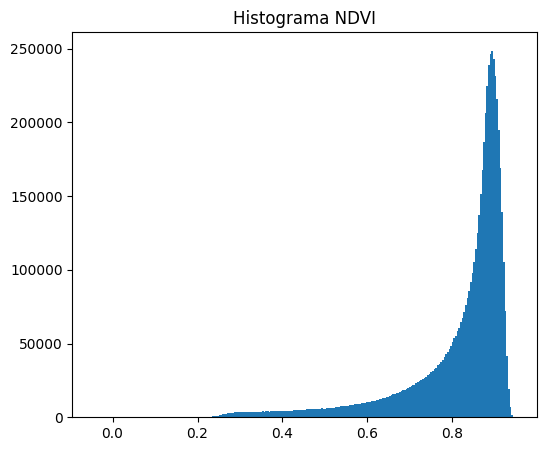

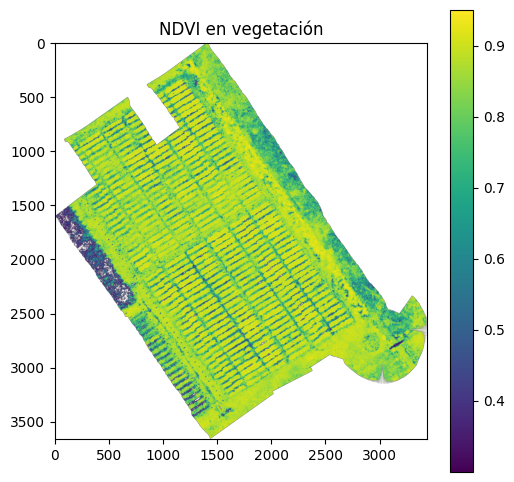

In [32]:
# Ayuda para buscar banda más cercana a una λ en nm
def nearest_band(target_nm):
    assert wavelengths is not None, "No hay vector de longitudes de onda en el HDR."
    return int(np.nanargmin(np.abs(wavelengths - target_nm)))

red_b = nearest_band(660)
nir_b = nearest_band(800)
re_b  = nearest_band(720)   # red-edge

red = to_reflectance(red_b)
nir = to_reflectance(nir_b)
re  = to_reflectance(re_b)

ndvi = (nir - red) / (nir + red + 1e-6)
ndre = (nir - re)  / (nir + re  + 1e-6)

# Umbrales heurísticos (ajustar tras ver histograma)
veg_mask = (ndvi > 0.3) & np.isfinite(ndvi) & np.isfinite(nir) & np.isfinite(red)

# Visual
plt.figure(figsize=(6,5)); plt.hist(ndvi[np.isfinite(ndvi)], bins=256); plt.title('Histograma NDVI'); plt.show()
plt.figure(figsize=(6,6)); plt.imshow(np.where(veg_mask, ndvi, np.nan), cmap='viridis'); plt.title('NDVI en vegetación'); plt.colorbar(); plt.show()

# 4) Limpieza espectral: bandas ruidosas + suavizado (Savitzky–Golay)

- Eliminar bandas en regiones típicas de absorción de agua si existen (ver wavelengths): aprox. 1340–1440 nm, 1800–1950 nm.
- Savitzky–Golay (eje espectral) para suavizar ruido de alta frecuencia sin perder forma espectral.

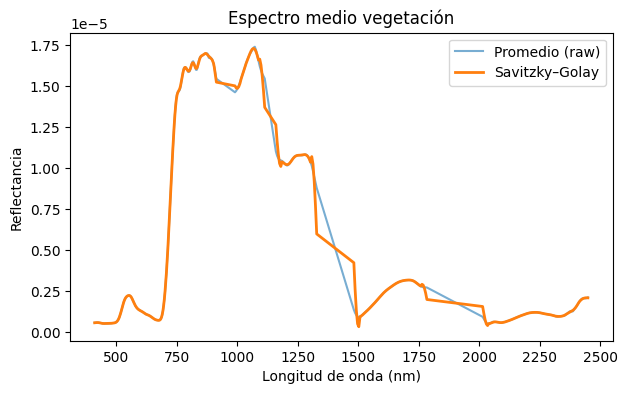

In [36]:
from scipy.signal import savgol_filter

valid_bands = np.arange(img.nbands)
if wavelengths is not None:
    water_mask = ((wavelengths > 1340) & (wavelengths < 1440)) | ((wavelengths > 1800) & (wavelengths < 1950))
    valid_bands = np.where(~water_mask)[0]

# Ejemplo: suavizar un espectro promedio de vegetación
ys, xs = np.where(veg_mask)
# Tomamos una muestra aleatoria de píxeles vegetación para diagnóstico
idx = np.random.choice(len(ys), size=min(2000, len(ys)), replace=False)

spec_stack = []
for bi in valid_bands:
    band = to_reflectance(bi)
    spec_stack.append(band[ys[idx], xs[idx]])
spec_stack = np.array(spec_stack)  # shape: [Bvalid, Nsamples]

spec_mean = np.nanmean(spec_stack, axis=1)
spec_sg   = savgol_filter(spec_mean, window_length=11, polyorder=3, mode='interp')

plt.figure(figsize=(7,4))
plt.plot(wavelengths[valid_bands], spec_mean, label='Promedio (raw)', alpha=0.6)
plt.plot(wavelengths[valid_bands], spec_sg,   label='Savitzky–Golay', linewidth=2)
plt.xlabel('Longitud de onda (nm)'); plt.ylabel('Reflectancia'); plt.legend(); plt.title('Espectro medio vegetación'); plt.show()


# 5) Quicklooks RGB/FC (PCA) para inspección

- Usa las default bands: ['79','48','18'] como RGB inicial.
- Genera una PCA sobre bandas válidas → false color informativo.

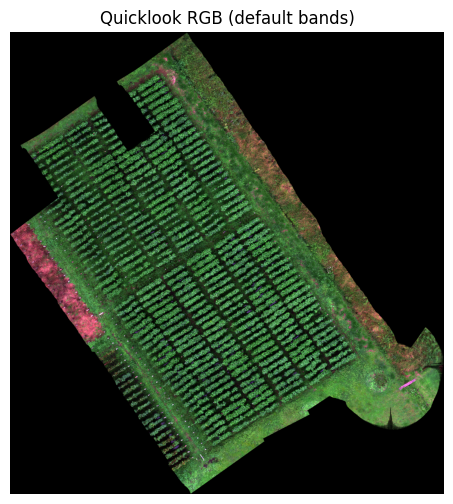

subsample
0
	 0
	 1
	 2
	 3
	 4
	 5
	 6
	 7
	 8
	 9
	 10
	 11
	 12
	 13
	 14
	 15
	 16
	 17
	 18
	 19
	 20
	 21
	 22
	 23
	 24
	 25
	 26
	 27
	 28
	 29
	 30
	 31
	 32
	 33
	 34
	 35
	 36
	 37
	 38
	 39
	 40
	 41
	 42
	 43
	 44
	 45
	 46
	 47
	 48
	 49
	 50
	 51
	 52
	 53
	 54
	 55
	 56
	 57
	 58
	 59
	 60
	 61
	 62
	 63
	 64
	 65
	 66
	 67
	 68
	 69
	 70
	 71
	 72
	 73
	 74
	 75
	 76
	 77
	 78
	 79
	 80
	 81
	 82
	 83
	 84
	 85
	 86
	 87
	 88
	 89
	 90
	 91
	 92
	 93
	 94
	 95
	 96
	 97
	 98
	 99
	 100
	 101
	 102
	 103
	 104
	 105
	 106
	 107
	 108
	 109
	 110
	 111
	 112
	 113
	 114
	 115
	 116
	 117
	 118
	 119
	 120
	 121
	 122
	 123
	 124
	 125
	 126
	 127
	 128
	 129
	 130
	 131
	 132
	 133
	 134
	 135
	 136
	 137
	 138
	 139
	 140
	 141
	 142
	 143
	 144
	 145
	 146
	 147
	 148
	 149
	 150
	 151
	 152
	 153
	 154
	 155
	 156
	 157
	 158
	 159
	 160
	 161
	 162
	 163
	 164
	 165
	 166
	 167
	 168
	 169
	 170
	 171
	 172
	 173
	 174
	 175
	 176
	 177
	 178
	 179
	 180
	 181
	 182


KeyboardInterrupt: 

In [44]:
from sklearn.decomposition import PCA

# Quicklook RGB por índices default del header (asegurando rango)
rgb_idx = [int(x) for x in ['79','48','18']]
rgb = []
for bi in rgb_idx:
    band = to_reflectance(bi)
    # normalizar a 0-1 con percentiles
    lo, hi = np.nanpercentile(band, [1, 99])
    rgb.append(np.clip((band - lo)/(hi - lo + 1e-6), 0, 1))
rgb = np.dstack(rgb)

plt.figure(figsize=(6,6))
plt.imshow(np.nan_to_num(rgb)); plt.title('Quicklook RGB (default bands)'); plt.axis('off'); plt.show()

# PCA (tomar subsample espacial para ajustar PCA)
print('subsample')
sample_rows = np.linspace(0, img.nrows-1, 300, dtype=int)
X = []
for r in sample_rows:
    print(r)
    row_vals = []
    for bi in valid_bands:
        print('\t',bi)
        band = to_reflectance(bi)
        row_vals.append(band[r, :])
    row_vals = np.array(row_vals).T  # [W, B]
    X.append(row_vals)
X = np.vstack(X)  # [Npixels_sub, B]
X = X[~np.any(~np.isfinite(X), axis=1)]
print('Iniciando PCA')
pca = PCA(n_components=3, random_state=0).fit(X)

print('PCA passed')
# Proyectar en tiles para no explotar memoria
def pca_quicklook(step=200):
    out = np.zeros((img.nrows, img.ncols, 3), dtype=np.float32)*np.nan
    for r0 in range(0, img.nrows, step):
        print(r0)
        r1 = min(r0+step, img.nrows)
        # construir bloque [Hblk*W, B]
        block = []
        for bi in valid_bands:
            print('\t',bi)
            band = to_reflectance(bi)[r0:r1, :]
            block.append(band)
        block = np.stack(block, axis=-1)  # [Hblk, W, B]
        shp = block.shape
        Xb = block.reshape(-1, shp[-1])
        mask = np.all(np.isfinite(Xb), axis=1)
        Y = np.zeros((Xb.shape[0], 3), dtype=np.float32)*np.nan
        Y[mask] = pca.transform(Xb[mask])
        Y = Y.reshape(shp[0], shp[1], 3)
        # escalar cada componente para visualización
        for k in range(3):
            print('\t\t',k)
            lo, hi = np.nanpercentile(Y[...,k], [1, 99])
            Y[...,k] = np.clip((Y[...,k]-lo)/(hi-lo+1e-6), 0, 1)
        out[r0:r1] = Y
    return out

pca_img = pca_quicklook(step=200)
plt.figure(figsize=(6,6)); plt.imshow(np.nan_to_num(pca_img)); plt.title('PCA False Color'); plt.axis('off'); plt.show()

# 6) Precálculo de índices espectrales relevantes (P/Nutrientes)
Aunque el diagnóstico específico de fósforo requiere modelado, es útil almacenar índices que correlacionan con estructura, pigmentos y estrés:

- NDVI, NDRE
- PRI (Photochemical Reflectance Index ~ 531 & 570 nm): sensibilidad a xantofilas/eficiencia fotoquímica.
- PSRI (Plant Senescence Reflectance Index ~ 678, 500, 750 nm): senescencia/pigmentos.
- CIgreen (chlorophyll index using green ~ 554 nm y NIR).
- MCARI2 (clorofila robusto a fondo).

Escoge las bandas más cercanas por wavelengths. Guarda cada índice como GeoTIFF con misma proyección y pixel size.

In [ ]:
import rasterio
from rasterio.transform import from_origin

# Helper para buscar banda cercana
def b(nm): return nearest_band(nm)

def safe_ratio(a, b): 
    return (a - b) / (a + b + 1e-6)

green = to_reflectance(b(554))
red   = to_reflectance(b(660))
nir   = to_reflectance(b(800))
re    = to_reflectance(b(720))
b531  = to_reflectance(b(531))
b570  = to_reflectance(b(570))
b678  = to_reflectance(b(678))
b500  = to_reflectance(b(500))
b750  = to_reflectance(b(750))

NDVI = safe_ratio(nir, red)
NDRE = safe_ratio(nir, re)
PRI  = (b531 - b570) / (b531 + b570 + 1e-6)
PSRI = (b678 - b500) / (b750 + 1e-6)
CIg  = (nir / (green + 1e-6)) - 1.0

# Guardado como GeoTIFF (usar georreferenciación desde header)
# Si el HDR tiene map info, puedes reconstruir transform; aquí ejemplo simple:
map_info = hdr.get('map info', None)
if map_info:
    # ENVI map info: ['UTM','1','1','x_ul','y_ul','px','py','zone','North','WGS-84','units=Meter']
    x_ul = float(map_info[3]); y_ul = float(map_info[4])
    px   = float(map_info[5]); py   = float(map_info[6])
    transform = from_origin(x_ul, y_ul, px, py)
    crs = "EPSG:32618"  # UTM 18N WGS84

    def write_gtiff(path, arr):
        profile = {
            'driver':'GTiff', 'height':arr.shape[0], 'width':arr.shape[1],
            'count':1, 'dtype':'float32', 'crs':crs, 'transform':transform,
            'compress':'DEFLATE', 'tiled':True, 'blockxsize':512, 'blockysize':512
        }
        with rasterio.open(path, 'w', **profile) as dst:
            dst.write(np.nan_to_num(arr, nan=-9999).astype('float32'), 1)
            dst.set_nodata(-9999)

    write_gtiff('data/derived/NDVI.tif', NDVI)
    write_gtiff('data/derived/NDRE.tif', NDRE)
    write_gtiff('data/derived/PRI.tif',  PRI)
    write_gtiff('data/derived/PSRI.tif', PSRI)
    write_gtiff('data/derived/CIgreen.tif', CIg)

# 7) Exportar cubo eficiente (COG o Zarr) para modelado

- COG (Cloud Optimized GeoTIFF): bueno para QGIS y lectura por bandas/ventanas.
- Zarr + xarray/dask: excelente para ML/experimentos chunked (eje espectral como dimensión).

Sugerencia: Exporta subset de bandas válidas + reflectancia float32 + NoData, en tiles 512×512.
(Código para COG multibanda es más extenso; puedo generarlo en el siguiente paso si quieres. Alternativamente, guarda cubos por bloques o por agrupaciones espectrales: visible, red-edge, NIR, SWIR.)

# 8) (Opcional) Superpixeles/SLIC para agregación por planta
Como tienes 2 cm/píxel, te conviene agrupar píxeles por planta (o por hoja) antes de etiquetar:

In [ ]:
from skimage.segmentation import slic
from skimage.util import img_as_float

# Usa un quicklook (ej. RGB) como imagen guía para SLIC
guidance = np.nan_to_num(rgb)  # [H,W,3] en 0-1
segments = slic(img_as_float(guidance), n_segments=8000, compactness=10, sigma=1, start_label=1)

plt.figure(figsize=(6,6)); plt.imshow(segments, cmap='tab20'); plt.title('Superpixeles (SLIC)'); plt.axis('off'); plt.show()

# Agregar espectros por superpixel (media robusta)
# => Útil para pseudoetiquetado y reducir ruido

# 9) Controles de calidad (QC) mínimos

Mapa de NoData (%) por bloque y por banda → detectar zonas problemáticas.
SNR proxy: std/mean por banda en vegetación.
Corr. entre bandas contiguas → identificar bandas inestables.
Reporte con gráficos guardados en data/interim/reports/.

# 10) Entregables del pipeline inicial

1. Cubo de reflectancia listo (subset de bandas válidas, float32, NoData).
2. Máscara de vegetación (veg_mask.tif).
3. Índices: NDVI, NDRE, PRI, PSRI, CIgreen (GeoTIFF).
4. Quicklooks: RGB y PCA (PNGs para inspección).
5. Lista de bandas válidas con longitudes de onda y FWHM (CSV).
6. (Opcional) Superpixeles (GeoTIFF de etiquetas) para agregación.

# 11) Checklist de robustez antes de pseudo-etiquetado

- [] Confirmar que wavelengths existe en el .hdr (si no, recuperar del fabricante/calibración).
- [] Verificar consistencia: data type vs archivo (tu header dice data type: 2 pero nombre sugiere float32). Si realmente es float32, ajusta lectura (e.g., vía rasterio con dtype=float32) o corrige el .hdr.
- [] Validar georreferenciación en QGIS (alineación con parcelas).
- [] Documentar bandas descartadas y motivos (absorción/ruido).
- [] Guardar parámetros (umbrales NDVI, ventana SG, etc.) en un YAML para reproducibilidad.

In [12]:
def downsample_lazy(img, step=10):
    """Crea una versión reducida sin cargar todo el cubo."""
    rows, cols, wavelegths = img.shape
    new_rows = rows // step
    new_cols = cols // step
    mini = np.zeros((new_rows, new_cols, wavelegths), dtype=np.float32)

    print(mini.shape)
    print(rows, cols, wavelegths)
    print(new_rows, new_cols)
    
    print(f"⏳ Generando mini-cubo con paso {step}...")
    for i_out, i in enumerate(range(0, rows, step)):
        print(i_out, i)
        for j_out, j in enumerate(range(0, cols, step)):
            print('\t', j_out, j)
            try:
                mini[i_out, j_out, :] = img[i, j, :]
            except: 
                pass
    return mini

mini_cubo = downsample_lazy(img, step=20)
print("✅ Mini-cubo generado:", mini_cubo.shape)

(183, 171, 379)
3660 3438 379
183 171
⏳ Generando mini-cubo con paso 20...
0 0
	 0 0
	 1 20
	 2 40
	 3 60
	 4 80
	 5 100
	 6 120
	 7 140
	 8 160
	 9 180
	 10 200
	 11 220
	 12 240
	 13 260
	 14 280
	 15 300
	 16 320
	 17 340
	 18 360
	 19 380
	 20 400
	 21 420
	 22 440
	 23 460
	 24 480
	 25 500
	 26 520
	 27 540
	 28 560
	 29 580
	 30 600
	 31 620
	 32 640
	 33 660
	 34 680
	 35 700
	 36 720
	 37 740
	 38 760
	 39 780
	 40 800
	 41 820
	 42 840
	 43 860
	 44 880
	 45 900
	 46 920
	 47 940
	 48 960
	 49 980
	 50 1000
	 51 1020
	 52 1040
	 53 1060
	 54 1080
	 55 1100
	 56 1120
	 57 1140
	 58 1160
	 59 1180
	 60 1200
	 61 1220
	 62 1240
	 63 1260
	 64 1280
	 65 1300
	 66 1320
	 67 1340
	 68 1360
	 69 1380
	 70 1400
	 71 1420
	 72 1440
	 73 1460
	 74 1480
	 75 1500
	 76 1520
	 77 1540
	 78 1560
	 79 1580
	 80 1600
	 81 1620
	 82 1640
	 83 1660
	 84 1680
	 85 1700
	 86 1720
	 87 1740
	 88 1760
	 89 1780
	 90 1800
	 91 1820
	 92 1840
	 93 1860
	 94 1880
	 95 1900
	 96 1920
	 97 1940
	 98 19

## Basic stadistics

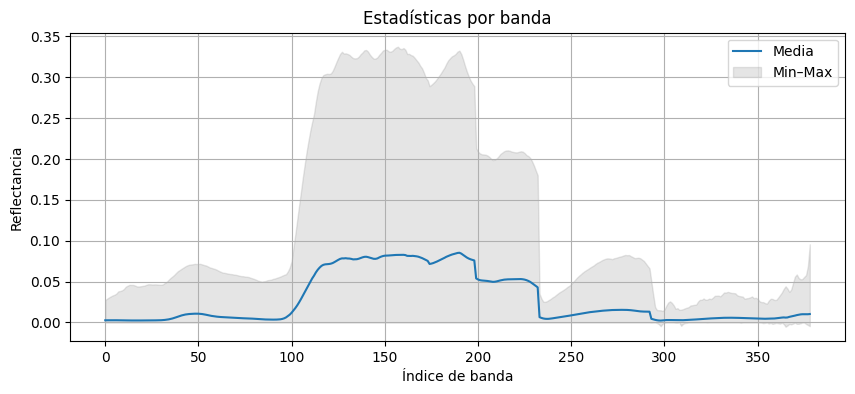

In [19]:
medias = [np.mean(mini_cubo[:, :, i]) for i in range(n_wavelegths)]
mins = [np.min(mini_cubo[:, :, i]) for i in range(n_wavelegths)]
maxs = [np.max(mini_cubo[:, :, i]) for i in range(n_wavelegths)]

plt.figure(figsize=(10,4))
plt.plot(medias, label='Media')
plt.fill_between(range(n_wavelegths), mins, maxs, color='gray', alpha=0.2, label='Min–Max')
plt.title("Estadísticas por banda")
plt.xlabel("Índice de banda")
plt.ylabel("Reflectancia")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
wavelegths

[411.03182,
 413.93909,
 416.84635,
 419.75362,
 422.66089,
 425.56816,
 428.47543,
 431.38269,
 434.28996,
 437.19723,
 440.1045,
 443.01177,
 445.91904,
 448.8263,
 451.73357,
 454.64084,
 457.54811,
 460.45538,
 463.36264,
 466.26991,
 469.17718,
 472.08445,
 474.99172,
 477.89898,
 480.80625,
 483.71352,
 486.62079,
 489.52806,
 492.43533,
 495.34259,
 498.24986,
 501.15713,
 504.0644,
 506.97167,
 509.87894,
 512.7862,
 515.69347,
 518.60074,
 521.50801,
 524.41528,
 527.32254,
 530.22981,
 533.13708,
 536.04435,
 538.95162,
 541.85889,
 544.76615,
 547.67342,
 550.58069,
 553.48796,
 556.39523,
 559.30249,
 562.20976,
 565.11703,
 568.0243,
 570.93157,
 573.83883,
 576.7461,
 579.65337,
 582.56064,
 585.46791,
 588.37517,
 591.28244,
 594.18971,
 597.09698,
 600.00425,
 602.91152,
 605.81878,
 608.72605,
 611.63332,
 614.54059,
 617.44786,
 620.35512,
 623.26239,
 626.16966,
 629.07693,
 631.9842,
 634.89147,
 637.79873,
 640.706,
 643.61327,
 646.52054,
 649.42781,
 652.33508,
 

# Visualization

## Direct visualization of the hyperspectral data

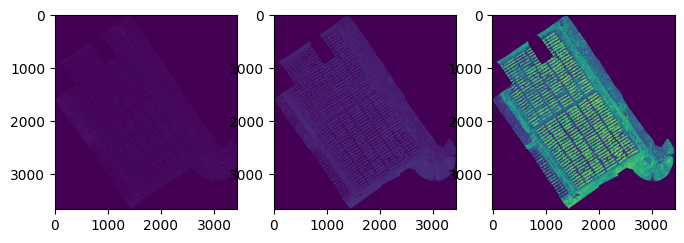

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(8, 25))
ax = ax.flatten()

ind = wavelegths.index(463.36264)
ax[0].imshow(img[:, :, ind])

ind = wavelegths.index(559.30249)
ax[1].imshow(img[:, :, ind])

ind = wavelegths.index(745.36766)
ax[2].imshow(img[:, :, ind])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1e-04..0.3133].


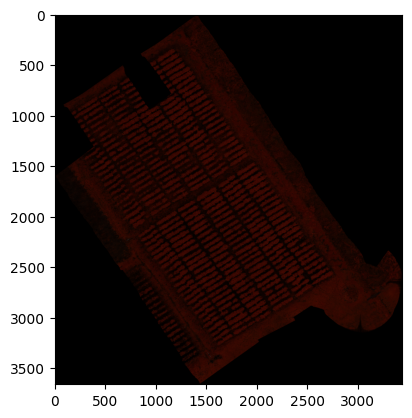

In [54]:
import numpy as np

img2 = np.zeros([3660, 3438, 3], np.float32)

ind1 = wavelegths.index(463.36264)
ind2 = wavelegths.index(559.30249)
ind3 = wavelegths.index(745.36766)

img2[:, :, 2] = np.squeeze(img[:, :, ind1])
img2[:, :, 1] = np.squeeze(img[:, :, ind2])
img2[:, :, 0] = np.squeeze(img[:, :, ind3])

plt.imshow(img2)

## Transform the image to uint8

In [55]:
ind_r = wavelegths.index(460.45538)
ind_g = wavelegths.index(547.67342)
ind_b = wavelegths.index(637.79873)

r, g, b = img[:, :, ind_r], img[:, :, ind_g], img[:, :, ind_b]

print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_r]):.4f}, Max: {np.max(img[:, :, ind_r]):.4f}")
print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_g]):.4f}, Max: {np.max(img[:, :, ind_g]):.4f}")
print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_b]):.4f}, Max: {np.max(img[:, :, ind_b]):.4f}")

Original data type: <i2, Min: -0.0001, Max: 0.2458
Original data type: <i2, Min: -0.0001, Max: 0.2739
Original data type: <i2, Min: -0.0001, Max: 0.2737


In [70]:
def scale_to_uint8(band):
    """Scales a single band to the 0-255 range and converts to uint8."""
    min_val = np.min(band)
    max_val = np.max(band)
    if max_val == min_val:
        scaled_band = np.zeros_like(band, dtype=np.uint8) + 127  # Avoid division by zero
    else:
        normalized_band = (band - min_val) / (max_val - min_val)
        scaled_band = (normalized_band * 255).astype(np.uint8)
    return scaled_band

# def scale_to_float(band):
#     """Escala una banda individual al rango 0-1 (float)."""
#     min_val = np.min(band)
#     max_val = np.max(band)
#     if max_val == min_val:
#         scaled_band = np.zeros_like(band, dtype=np.float32) + 0.5  # Evitar división por cero
#     else:
#         scaled_band = (band - min_val) / (max_val - min_val)
#     return scaled_band

scaled_red = scale_to_uint8(r)
scaled_green = scale_to_uint8(g)
scaled_blue = scale_to_uint8(b)

print(f"Original data type: {scaled_red.dtype}, Min: {np.min(scaled_red):.4f}, Max: {np.max(scaled_red):.4f}")
print(f"Original data type: {scaled_green.dtype}, Min: {np.min(scaled_green):.4f}, Max: {np.max(scaled_green):.4f}")
print(f"Original data type: {scaled_blue.dtype}, Min: {np.min(scaled_blue):.4f}, Max: {np.max(scaled_blue):.4f}")

Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000


In [71]:
scaled_red.shape

(3660, 3438, 1)

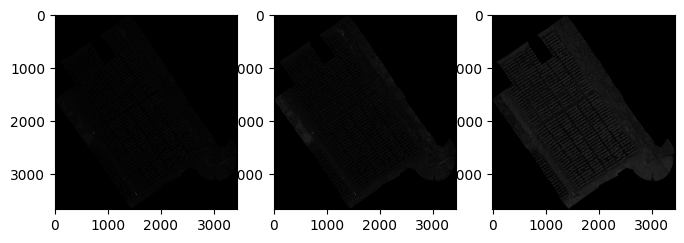

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(8, 10))
ax = ax.flatten()

rgb = cv2.cvtColor(scaled_red, cv2.COLOR_BGR2RGB)
ax[0].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_blue, cv2.COLOR_BGR2RGB)
ax[1].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_green, cv2.COLOR_BGR2RGB)
ax[2].imshow(rgb, cmap = plt.cm.Spectral)

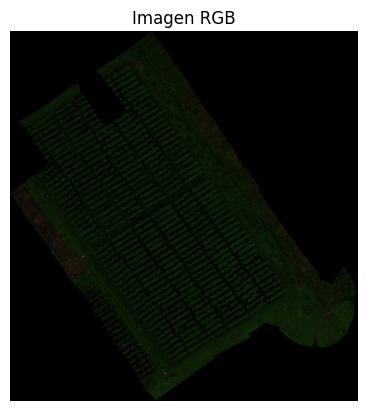

In [74]:
rgb_image = cv2.merge([scaled_blue, scaled_green, scaled_red])
# rgb_image = cv2.merge([scaled_red, scaled_green, scaled_blue])

# Muestra la imagen usando matplotlib
plt.imshow(rgb_image)
plt.title("Imagen RGB")
plt.axis('off')  # Para no mostrar los ejes
plt.show()